`quick-start.ipynb`

- .env에 TAVILY_API_KEY 넣어야함

## Deep Agent
기존 Langchain Agent 보다 아래 능력을 포함
1. 계획 세우기
1. 파일 시스템 Tools
1. 하위 에이전트

In [7]:
from dotenv import load_dotenv
load_dotenv()

True

In [8]:
import os
from typing import Literal
from tavily import TavilyClient
from langchain.tools import tool



TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')
tavily_client = TavilyClient(api_key=TAVILY_API_KEY)

@tool
def internet_search(
        query:str,
        max_results: int = 5, # = 뒤에는 기본값
        topic: Literal['general', 'news', 'finance'] = 'general',
        include_raw_content: bool = False,
):
    """Run a web search"""
    return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic
    )

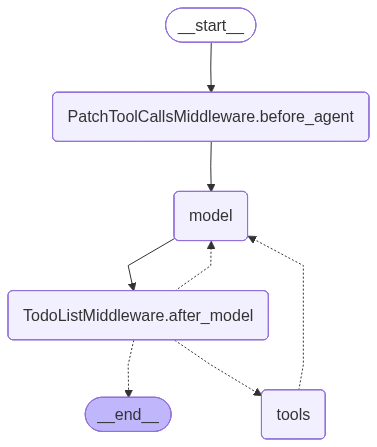

In [ ]:
from deepagents import create_deep_agent

# deep agent 만들기
SYSTEM_PROMPT="""You are an expert researcher. Your job is to conduct thorough research and then write a polished report.

You have access to an internet search tool as your primary means of gathering information.

## `internet_search`

Use this to run an internet search for a given query. You can specify the max number of results to return, the topic, and whether raw content should be included.
"""

deep_agent = create_deep_agent(
    model='openai:gpt-5-mini',
    tools=[internet_search],
    system_prompt=SYSTEM_PROMPT
)

deep_agent

In [11]:
question ="""
랭체인 1.0 버전 전과 후를 비교해줘. 
langchain, langgraph, langsmith에 대해서 설명 및 달라진 점 말해주고, 
deepagent가 새로 나왔는데 그것도 알려줘.
"""
deep_agent.invoke({
    'messages': [
        {'role': 'user', 'content': question}
    ]
})

{'messages': [HumanMessage(content='\n랭체인 1.0 버전 전과 후를 비교해줘. \nlangchain, langgraph, langsmith에 대해서 설명 및 달라진 점 말해주고, \ndeepagent가 새로 나왔는데 그것도 알려줘.\n', additional_kwargs={}, response_metadata={}, id='286e15fd-94de-4980-9412-6a7dedd7639f'),
  AIMessage(content=[{'id': 'rs_0d2e0bef29562acc0069af7ab11ad08195ab892018b26da428', 'summary': [], 'type': 'reasoning'}, {'arguments': '{"query":"LangChain 1.0 changes pre and post 1.0", "max_results": 5, "topic": "general", "include_raw_content": false}', 'call_id': 'call_bOGAX2UAWKkun4rupCVSc7k5', 'name': 'internet_search', 'type': 'function_call', 'id': 'fc_0d2e0bef29562acc0069af7ab311ac8195befe75e2441a0ffa', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0d2e0bef29562acc0069af7ab0c110819588534fc886441ac1', 'created_at': 1773107888.0, 'metadata': {}, 'model': 'gpt-5-nano-2025-08-07', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-0